<a href="https://colab.research.google.com/github/ankush-7-code/pap-smear-noise-removal-roi-segmentation/blob/main/NoiseRemoval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python-headless scikit-image numpy matplotlib

Saving K-CV-1904662-140032_jpg.rf.068582b2c14aeff35e57c9cfd13b57bc.jpg to K-CV-1904662-140032_jpg.rf.068582b2c14aeff35e57c9cfd13b57bc.jpg


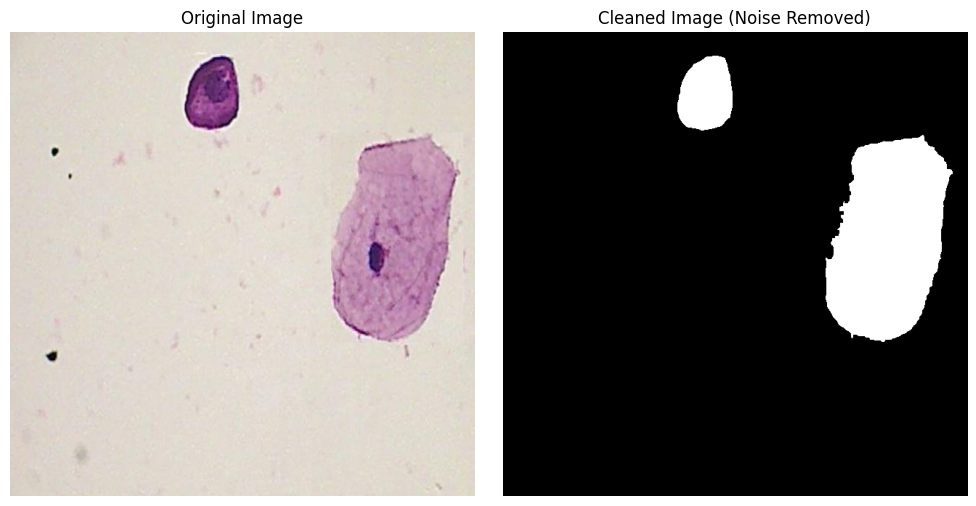

In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
from skimage.morphology import remove_small_objects
from skimage.filters import threshold_otsu
from skimage.color import rgb2gray

# Upload the file
uploaded = files.upload()

# Get the name of the uploaded file (the filename in the uploaded dictionary)
image_path = next(iter(uploaded))  # This gets the first uploaded file name

# Function to process the image and remove noise
def remove_noise(image_path):
    # Load the image (as grayscale)
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)

    # Check if the image was loaded successfully
    if img is None:
        print(f"Error: Could not load image at path: {image_path}")
        return None, None  # Return None for both outputs if image loading fails

    # Convert the image to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Use Otsu's thresholding method to separate foreground and background
    _, thresholded = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Morphological operations to clean up small objects
    kernel = np.ones((5, 5), np.uint8)
    clean_img = cv2.morphologyEx(thresholded, cv2.MORPH_CLOSE, kernel)

    # Remove small objects using skimage's remove_small_objects (useful for tiny noisy objects)
    cleaned_img = remove_small_objects(clean_img.astype(bool), min_size=500, connectivity=2)

    # Convert the cleaned image back to uint8
    cleaned_img = (cleaned_img * 255).astype(np.uint8)

    # Find contours in the cleaned image to highlight the cells
    contours, _ = cv2.findContours(cleaned_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Draw contours on the original image
    result_img = img.copy()
    cv2.drawContours(result_img, contours, -1, (0, 255, 0), 2)

    return result_img, cleaned_img

# Display the original and cleaned images
def display_results(image_path):
    result_img, cleaned_img = remove_noise(image_path)

    if result_img is None:
        return

    # Plot the original and cleaned images side by side
    plt.figure(figsize=(10, 5))

    # Original Image
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")

    # Cleaned Image
    plt.subplot(1, 2, 2)
    plt.imshow(cleaned_img, cmap='gray')
    plt.title("Cleaned Image (Noise Removed)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# Call the display function with your uploaded image
display_results(image_path)


Saving K-CV-1904662-140116_jpg.rf.bbf2e2d9fed2669ce93d360a9780cbd1.jpg to K-CV-1904662-140116_jpg.rf.bbf2e2d9fed2669ce93d360a9780cbd1.jpg


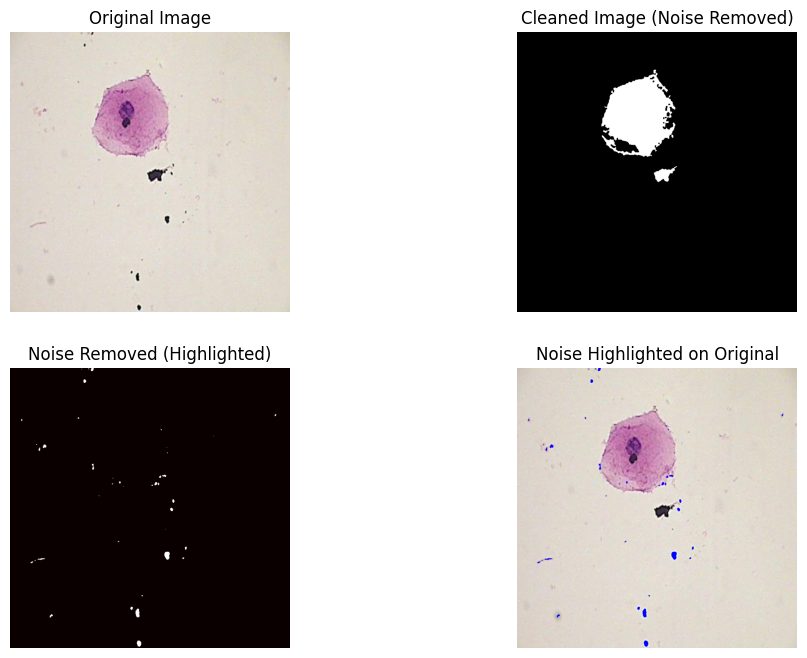

In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import remove_small_objects

# Upload the file
uploaded = files.upload()
image_path = next(iter(uploaded))  # Get the first uploaded file name

def remove_noise(image_path):
    # Load the image
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)

    if img is None:
        print(f"Error: Could not load image at {image_path}")
        return None, None, None, None

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian blur
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Otsu's thresholding
    _, thresholded = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Morphological operations
    kernel = np.ones((3, 3), np.uint8)
    clean_img = cv2.morphologyEx(thresholded, cv2.MORPH_CLOSE, kernel)

    # Remove small objects
    cleaned_img = remove_small_objects(clean_img > 0, min_size=500, connectivity=2)
    cleaned_img = (cleaned_img * 255).astype(np.uint8)

    # Identify removed noise (Difference between original thresholded and cleaned)
    noise_removed = cv2.subtract(thresholded, cleaned_img)

    # Highlight removed noise in red on the original image
    noise_overlay = img.copy()
    noise_overlay[np.where(noise_removed > 0)] = [255, 0, 0]  # Red overlay for removed noise

    return img, cleaned_img, noise_removed, noise_overlay

def display_results(image_path):
    original, cleaned_img, noise_removed, noise_overlay = remove_noise(image_path)

    if original is None:
        return

    # Display the images
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(2, 2, 2)
    plt.imshow(cleaned_img, cmap='gray')
    plt.title("Cleaned Image (Noise Removed)")
    plt.axis("off")

    plt.subplot(2, 2, 3)
    plt.imshow(noise_removed, cmap='hot')
    plt.title("Noise Removed (Highlighted)")
    plt.axis("off")

    plt.subplot(2, 2, 4)
    plt.imshow(cv2.cvtColor(noise_overlay, cv2.COLOR_BGR2RGB))
    plt.title("Noise Highlighted on Original")
    plt.axis("off")

    plt.show()

# Run the function
display_results(image_path)


Saving K-CV-1904662-140116_jpg.rf.bbf2e2d9fed2669ce93d360a9780cbd1.jpg to K-CV-1904662-140116_jpg.rf.bbf2e2d9fed2669ce93d360a9780cbd1 (1).jpg


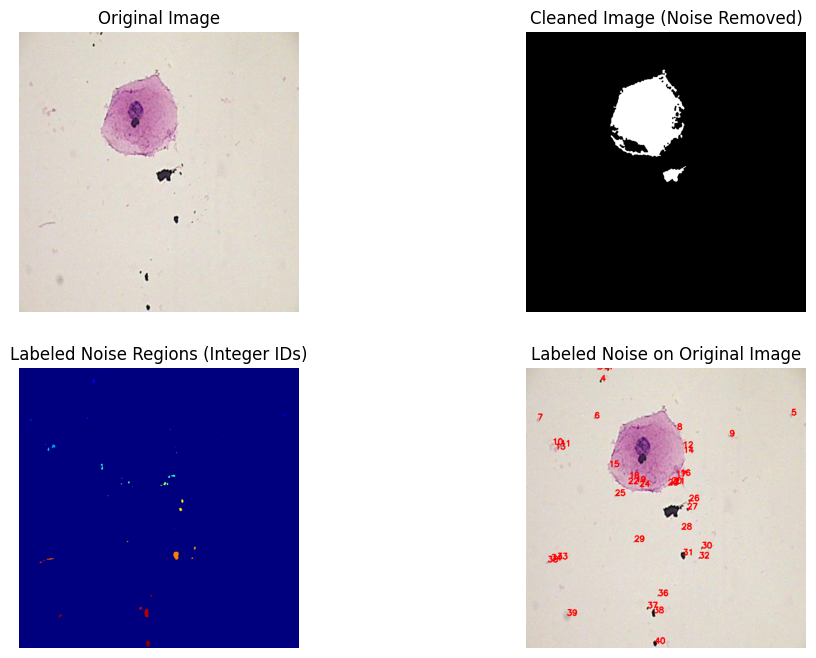

In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import remove_small_objects
from skimage.measure import label, regionprops

# Upload the file
uploaded = files.upload()
image_path = next(iter(uploaded))  # Get the first uploaded file name

def remove_noise(image_path):
    # Load the image
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)

    if img is None:
        print(f"Error: Could not load image at {image_path}")
        return None, None, None, None

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian blur
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Otsu's thresholding
    _, thresholded = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Morphological operations
    kernel = np.ones((3, 3), np.uint8)
    clean_img = cv2.morphologyEx(thresholded, cv2.MORPH_CLOSE, kernel)

    # Remove small objects
    cleaned_img = remove_small_objects(clean_img > 0, min_size=500, connectivity=2)
    cleaned_img = (cleaned_img * 255).astype(np.uint8)

    # Identify removed noise (Difference between original thresholded and cleaned)
    noise_removed = cv2.subtract(thresholded, cleaned_img)

    # Label each noise region with a unique integer
    labeled_noise, num_labels = label(noise_removed > 0, return_num=True, connectivity=2)

    # Overlay labels on the image
    noise_labeled_img = img.copy()
    props = regionprops(labeled_noise)

    for i, prop in enumerate(props, start=1):  # Start numbering from 1
        y, x = prop.centroid
        cv2.putText(noise_labeled_img, str(i), (int(x), int(y)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)  # Red label

    return img, cleaned_img, labeled_noise, noise_labeled_img

def display_results(image_path):
    original, cleaned_img, labeled_noise, noise_labeled_img = remove_noise(image_path)

    if original is None:
        return

    # Display the images
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(2, 2, 2)
    plt.imshow(cleaned_img, cmap='gray')
    plt.title("Cleaned Image (Noise Removed)")
    plt.axis("off")

    plt.subplot(2, 2, 3)
    plt.imshow(labeled_noise, cmap='jet')
    plt.title("Labeled Noise Regions (Integer IDs)")
    plt.axis("off")

    plt.subplot(2, 2, 4)
    plt.imshow(cv2.cvtColor(noise_labeled_img, cv2.COLOR_BGR2RGB))
    plt.title("Labeled Noise on Original Image")
    plt.axis("off")

    plt.show()

# Run the function
display_results(image_path)



Saving K-CV-1904662-140116_jpg.rf.bbf2e2d9fed2669ce93d360a9780cbd1.jpg to K-CV-1904662-140116_jpg.rf.bbf2e2d9fed2669ce93d360a9780cbd1 (2).jpg


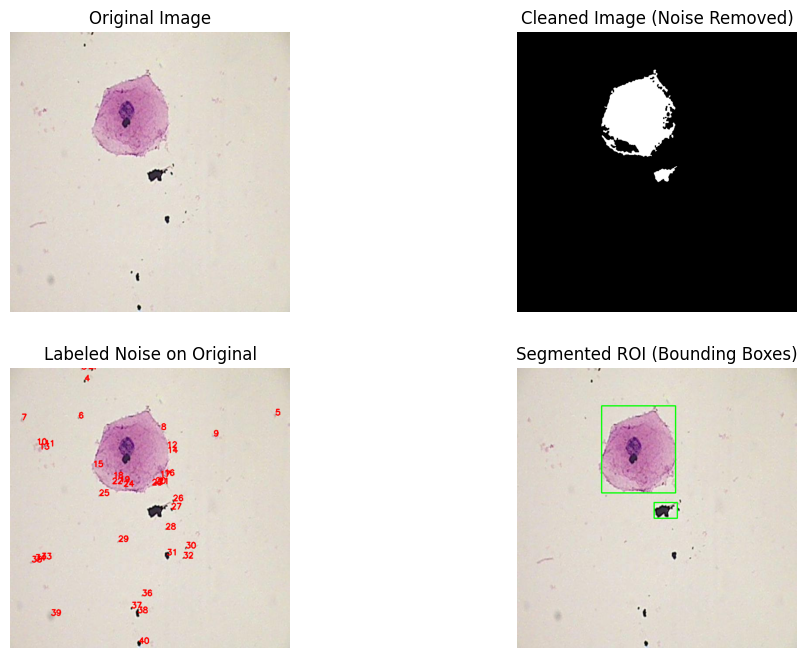

In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import remove_small_objects
from skimage.measure import label, regionprops

# Upload the file
uploaded = files.upload()
image_path = next(iter(uploaded))  # Get the first uploaded file name

def segment_roi(image_path):
    # Load the image
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)

    if img is None:
        print(f"Error: Could not load image at {image_path}")
        return None, None, None, None, None

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian blur
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Otsu's thresholding
    _, thresholded = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Morphological operations
    kernel = np.ones((3, 3), np.uint8)
    clean_img = cv2.morphologyEx(thresholded, cv2.MORPH_CLOSE, kernel)

    # Remove small objects (Noise)
    cleaned_img = remove_small_objects(clean_img > 0, min_size=500, connectivity=2)
    cleaned_img = (cleaned_img * 255).astype(np.uint8)

    # Identify removed noise
    noise_removed = cv2.subtract(thresholded, cleaned_img)

    # Label noise regions
    labeled_noise, num_labels = label(noise_removed > 0, return_num=True, connectivity=2)

    # Create an image with noise labeled
    noise_labeled_img = img.copy()
    props = regionprops(labeled_noise)

    for i, prop in enumerate(props, start=1):  # Start numbering from 1
        y, x = prop.centroid
        cv2.putText(noise_labeled_img, str(i), (int(x), int(y)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)  # Red label

    # **SEGMENTATION OF ROI (DRAW RECTANGLES)**
    contours, _ = cv2.findContours(cleaned_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Copy the original image to draw rectangles
    roi_img = img.copy()

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)  # Get bounding box
        cv2.rectangle(roi_img, (x, y), (x + w, y + h), (0, 255, 0), 2)  # Draw green rectangle

    return img, cleaned_img, noise_labeled_img, roi_img

def display_results(image_path):
    original, cleaned_img, noise_labeled_img, roi_img = segment_roi(image_path)

    if original is None:
        return

    # Display the images
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(2, 2, 2)
    plt.imshow(cleaned_img, cmap='gray')
    plt.title("Cleaned Image (Noise Removed)")
    plt.axis("off")

    plt.subplot(2, 2, 3)
    plt.imshow(cv2.cvtColor(noise_labeled_img, cv2.COLOR_BGR2RGB))
    plt.title("Labeled Noise on Original")
    plt.axis("off")

    plt.subplot(2, 2, 4)
    plt.imshow(cv2.cvtColor(roi_img, cv2.COLOR_BGR2RGB))
    plt.title("Segmented ROI (Bounding Boxes)")
    plt.axis("off")

    plt.show()

# Run the function
display_results(image_path)


Saving K-CV-1904662-140020_jpg.rf.357890a835d00475c2a02454ee867540.jpg to K-CV-1904662-140020_jpg.rf.357890a835d00475c2a02454ee867540.jpg


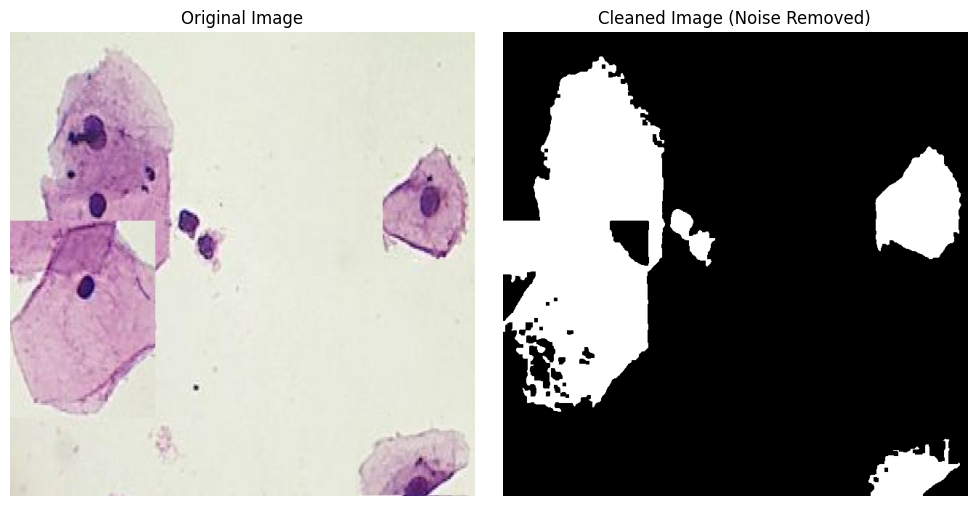

In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
from skimage.morphology import remove_small_objects
from skimage.filters import threshold_otsu
from skimage.color import rgb2gray

# Upload the file
uploaded = files.upload()

# Get the name of the uploaded file (the filename in the uploaded dictionary)
image_path = next(iter(uploaded))  # This gets the first uploaded file name

# Function to process the image and remove noise
def remove_noise(image_path):
    # Load the image (as grayscale)
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)

    # Check if the image was loaded successfully
    if img is None:
        print(f"Error: Could not load image at path: {image_path}")
        return None, None  # Return None for both outputs if image loading fails

    # Convert the image to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Use Otsu's thresholding method to separate foreground and background
    _, thresholded = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Morphological operations to clean up small objects
    kernel = np.ones((5, 5), np.uint8)
    clean_img = cv2.morphologyEx(thresholded, cv2.MORPH_CLOSE, kernel)

    # Remove small objects using skimage's remove_small_objects (useful for tiny noisy objects)
    cleaned_img = remove_small_objects(clean_img.astype(bool), min_size=500, connectivity=2)

    # Convert the cleaned image back to uint8
    cleaned_img = (cleaned_img * 255).astype(np.uint8)

    # Find contours in the cleaned image to highlight the cells
    contours, _ = cv2.findContours(cleaned_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Draw contours on the original image
    result_img = img.copy()
    cv2.drawContours(result_img, contours, -1, (0, 255, 0), 2)

    return result_img, cleaned_img

# Display the original and cleaned images
def display_results(image_path):
    result_img, cleaned_img = remove_noise(image_path)

    if result_img is None:
        return

    # Plot the original and cleaned images side by side
    plt.figure(figsize=(10, 5))

    # Original Image
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")

    # Cleaned Image
    plt.subplot(1, 2, 2)
    plt.imshow(cleaned_img, cmap='gray')
    plt.title("Cleaned Image (Noise Removed)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# Call the display function with your uploaded image
display_results(image_path)
